# 🤖 Máquina de Soporte Vectorial (SVM) — Dataset Iris
**Diplomado en Redes Neuronales y Deep Learning**

Este notebook cubre:
1. ¿Qué es una SVM y cómo funciona?
2. Carga del dataset (primeras 100 muestras)
3. Preprocesamiento: Normalización y One-Hot Encoding
4. Reducción 4D → 2D para visualizar el hiperplano
5. Visualización con regiones de color
6. Visualización del hiperplano y márgenes
7. Modelo completo con las 4 features
8. Comparativa de kernels
9. Predicción con flor nueva

---
## 🧠 1. ¿Qué es una SVM?

Una **Máquina de Soporte Vectorial** busca el **hiperplano** que mejor separa las clases, maximizando el **margen** entre ellas.

### Conceptos clave:

| Concepto | Qué es |
|---|---|
| **Hiperplano** | La 'línea' de separación (en 2D es una línea, en 3D un plano, en 4D un hiperplano) |
| **Margen** | La distancia entre el hiperplano y los puntos más cercanos de cada clase |
| **Vectores de soporte** | Los puntos de datos más cercanos al hiperplano — los que 'sostienen' el margen |
| **Kernel** | Truco matemático para manejar datos no separables linealmente |
| **C** | Parámetro de regularización: C alto = menos errores pero puede overfit |

### ¿Por qué 4D → 2D?
El dataset Iris tiene **4 features** (4 dimensiones). Los humanos no podemos visualizar 4D,
así que seleccionamos **2 features** para poder **graficar el hiperplano** y entender cómo trabaja la SVM.

---
## 📦 2. Importaciones y carga del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

iris = load_iris()

# Tomamos solo las primeras 100 muestras
# Setosa (filas 0-49) y Versicolor (filas 50-99) — Virginica queda fuera
X = iris.data[:100]
y = iris.target[:100]

feature_names = iris.feature_names
class_names   = iris.target_names[:2]  # Solo setosa y versicolor

df = pd.DataFrame(X, columns=feature_names)
df['especie'] = pd.Categorical.from_codes(y, class_names)

print(f"Muestras totales: {len(df)} (50 setosa + 50 versicolor)")
print(f"Features: {list(feature_names)}")
print(f"Clases usadas: {list(class_names)}")
print()
display(df.head(8))

Muestras totales: 100 (50 setosa + 50 versicolor)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Clases usadas: [np.str_('setosa'), np.str_('versicolor')]



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa


---
## 🔧 3. Preprocesamiento

### ¿Por qué normalizar para SVM?

La SVM calcula **distancias** entre puntos para encontrar el margen máximo.
Si una feature va de 0 a 1000 y otra de 0 a 1, la primera dominaría el cálculo aunque no sea más importante.

**`StandardScaler`** transforma cada feature para que tenga media=0 y desviación estándar=1.

⚠️ **Regla importante**: Ajustar el scaler SOLO con datos de entrenamiento (`fit_transform`),
y aplicarlo a test sin reajustar (`transform`). Si no, hay **data leakage**.

In [2]:
# --- 3.1 División Train/Test ANTES de normalizar ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")

# --- 3.2 Normalización ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # aprende media/std del train Y transforma
X_test_scaled  = scaler.transform(X_test)        # aplica la misma escala (sin reaprender)

print("\nAntes de normalizar (primeras 3 filas train):")
print(X_train[:3].round(3))
print("\nDespués de normalizar:")
print(X_train_scaled[:3].round(3))
print("\nMedia después de escalar (debe ser ~0):", X_train_scaled.mean(axis=0).round(4))
print("Std  después de escalar (debe ser ~1):",  X_train_scaled.std(axis=0).round(4))

Train: 70 muestras | Test: 30 muestras

Antes de normalizar (primeras 3 filas train):
[[4.8 3.4 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [6.  3.4 4.5 1.6]]

Después de normalizar:
[[-1.028  0.727 -0.926 -1.093]
 [-1.329  0.29  -1.069 -1.093]
 [ 0.775  0.727  1.14   1.428]]

Media después de escalar (debe ser ~0): [ 0.  0.  0. -0.]
Std  después de escalar (debe ser ~1): [1. 1. 1. 1.]


DataFrame con One-Hot Encoding:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie_setosa,especie_versicolor
0,5.1,3.5,1.4,0.2,1,0
1,4.9,3.0,1.4,0.2,1,0
2,4.7,3.2,1.3,0.2,1,0
3,4.6,3.1,1.5,0.2,1,0
4,5.0,3.6,1.4,0.2,1,0
5,5.4,3.9,1.7,0.4,1,0


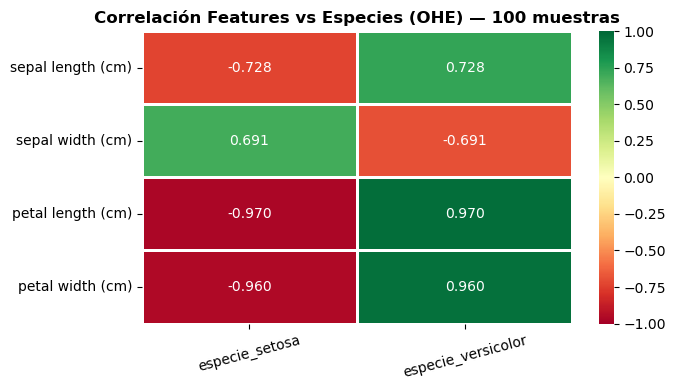


💡 petal length y petal width tienen mayor correlación → las usamos para visualizar en 2D.


In [3]:
# --- 3.3 One-Hot Encoding de la especie (para análisis de correlación) ---
df_ohe = pd.get_dummies(df, columns=['especie'], dtype=int)

print("DataFrame con One-Hot Encoding:")
display(df_ohe.head(6))

corr = df_ohe.corr().round(3)
especies_ohe = [c for c in df_ohe.columns if 'especie_' in c]
corr_feat_esp = corr.loc[feature_names, especies_ohe]

plt.figure(figsize=(7, 4))
sns.heatmap(corr_feat_esp, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=1, vmin=-1, vmax=1)
plt.title('Correlación Features vs Especies (OHE) — 100 muestras',
          fontsize=12, fontweight='bold')
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n💡 petal length y petal width tienen mayor correlación → las usamos para visualizar en 2D.")

---
## 📉 4. Reducción 4D → 2D: selección de 2 features

Para **visualizar** el hiperplano necesitamos 2 dimensiones.
Usamos las columnas 2 y 3 (índices 2:4): **petal length** y **petal width**,
que son las más discriminativas según la correlación.

In [4]:
# Tomamos solo las primeras 100 flores y las columnas 2 y 3 (petal length y petal width)
X_2d = X[:100, 2:4]
y_2d = y[:100]
feat_2d = [feature_names[2], feature_names[3]]

print(f"Forma original:    {X.shape}   → 4 features")
print(f"Forma reducida 2D: {X_2d.shape} → 2 features seleccionadas")
print(f"Features usadas:   {feat_2d}")

# División y normalización para el modelo 2D
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d, y_2d, test_size=0.3, random_state=42
)
scaler_2d = StandardScaler()
X2_train_s = scaler_2d.fit_transform(X2_train)
X2_test_s  = scaler_2d.transform(X2_test)

print(f"\nTrain 2D: {X2_train_s.shape} | Test 2D: {X2_test_s.shape}")

Forma original:    (100, 4)   → 4 features
Forma reducida 2D: (100, 2) → 2 features seleccionadas
Features usadas:   ['petal length (cm)', 'petal width (cm)']

Train 2D: (70, 2) | Test 2D: (30, 2)


---
## 🎯 5. Visualización con regiones de color

Pintamos el espacio completo según la clase que predice la SVM en cada punto.
Los **vectores de soporte** son los puntos con borde negro — los más cercanos a la frontera.

In [5]:
svm_2d = SVC(kernel='linear', C=1.0, random_state=42)
svm_2d.fit(X2_train_s, y2_train)

acc_2d = svm_2d.score(X2_test_s, y2_test)
print(f"SVM 2D (kernel=linear) — Precisión test: {acc_2d*100:.2f}%")
print(f"Vectores de soporte: {svm_2d.n_support_} → {class_names[0]}: {svm_2d.n_support_[0]}, {class_names[1]}: {svm_2d.n_support_[1]}")

SVM 2D (kernel=linear) — Precisión test: 100.00%
Vectores de soporte: [2 2] → setosa: 2, versicolor: 2


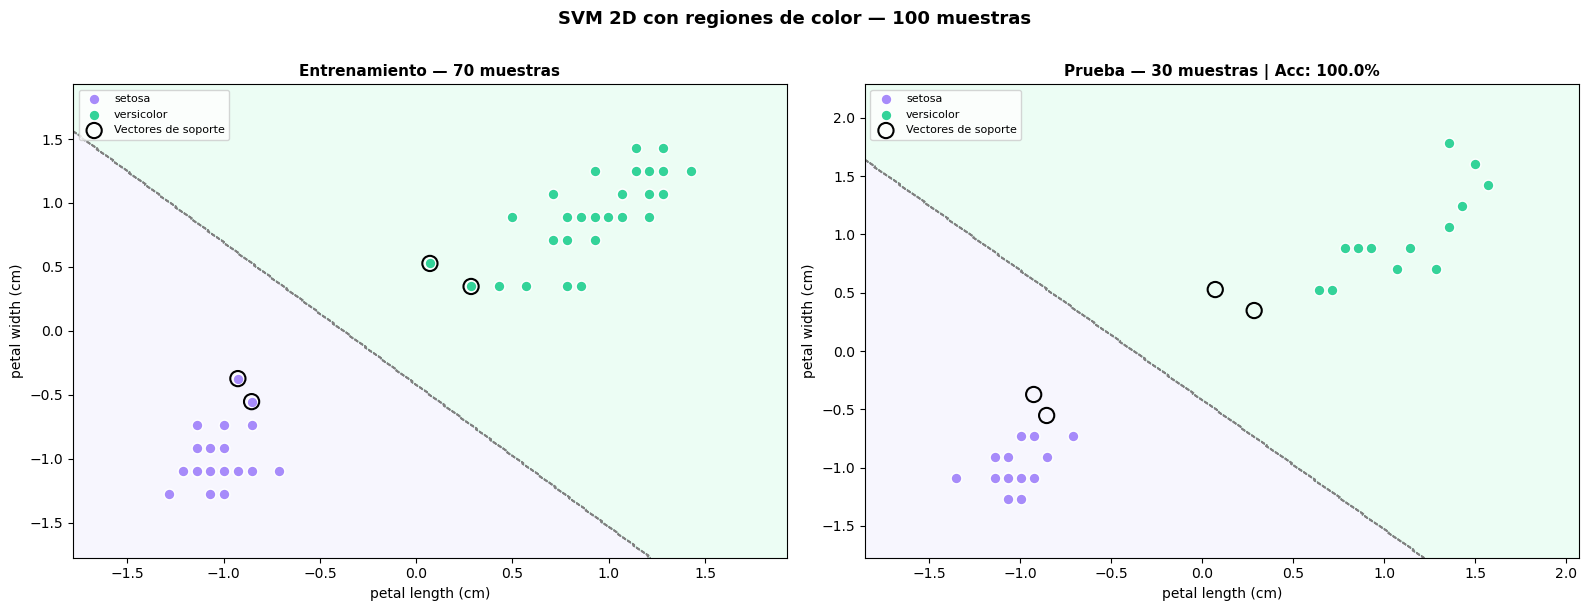

💡 Cada color de fondo = región donde la SVM clasifica esa especie.
   Puntos con borde negro = vectores de soporte (los que definen el margen).


In [6]:
def plot_decision_boundary(modelo, X_scaled, y, feat_names, titulo, ax):
    """Dibuja la frontera de decisión con regiones de color."""
    from matplotlib.colors import ListedColormap
    colores   = ['#a78bfa', '#34d399']
    colores_f = ['#ede9fe', '#d1fae5']

    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))

    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=ListedColormap(colores_f))
    ax.contour(xx, yy, Z, colors='gray', linewidths=0.8, linestyles='--')

    nombres = list(class_names) if len(np.unique(y)) == 2 else list(iris.target_names)
    for i, (nombre, color) in enumerate(zip(nombres, colores)):
        mask = y == i
        ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                   c=color, label=nombre, edgecolors='white', s=60, zorder=3)

    sv = modelo.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none',
               edgecolors='black', linewidths=1.5, zorder=4, label='Vectores de soporte')
    ax.set_xlabel(feat_names[0], fontsize=10)
    ax.set_ylabel(feat_names[1], fontsize=10)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_decision_boundary(svm_2d, X2_train_s, y2_train, feat_2d,
                       f'Entrenamiento — {len(X2_train_s)} muestras', axes[0])
plot_decision_boundary(svm_2d, X2_test_s, y2_test, feat_2d,
                       f'Prueba — {len(X2_test_s)} muestras | Acc: {acc_2d*100:.1f}%', axes[1])
plt.suptitle('SVM 2D con regiones de color — 100 muestras',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("💡 Cada color de fondo = región donde la SVM clasifica esa especie.")
print("   Puntos con borde negro = vectores de soporte (los que definen el margen).")

---
## 📐 6. Visualización del Hiperplano y Márgenes

Esta visualización muestra las **tres líneas** del SVM:
- Línea sólida (`level=0`) → el **hiperplano** real, la frontera de decisión
- Líneas punteadas (`level=-1` y `level=1`) → los **márgenes**, las 'banquetas' a cada lado

La SVM maximiza la distancia entre esas dos líneas punteadas.
Los vectores de soporte son exactamente los puntos que tocan esas banquetas.

> ⚠️ **Nota sobre el código del profe**: La versión original llamaba `ax.get_xlim()` antes
> de graficar los puntos, lo que devolvía límites por default (0,1) en lugar del rango real
> de los datos. Aquí primero se grafican los puntos, después se obtienen los límites.

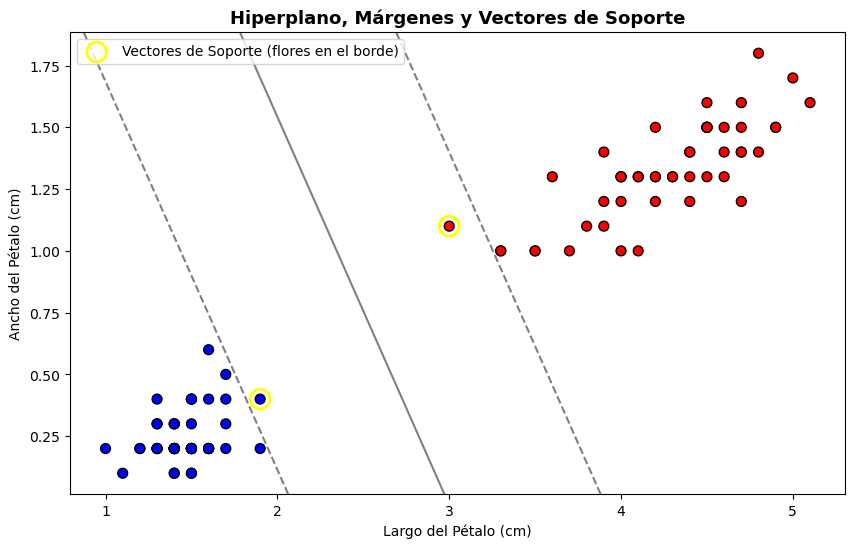

💡 ¿Qué estamos viendo?
   Línea sólida  → hiperplano (la frontera de decisión)
   Líneas punteadas → márgenes (-1 y +1)
   Puntos con borde amarillo → vectores de soporte (tocan exactamente el margen)
   La SVM busca que esas líneas punteadas estén lo más separadas posible.


In [7]:
# Entrenamos sin escalar (como el profe) porque en este caso las features ya están en escala similar
X_2d_raw = X[:100, 2:4]
y_2d_raw = y[:100]

svm_visual = SVC(kernel='linear', C=1.0)
svm_visual.fit(X_2d_raw, y_2d_raw)

plt.figure(figsize=(10, 6))
ax = plt.gca()

# PASO 1: Primero graficamos los puntos
plt.scatter(X_2d_raw[:, 0], X_2d_raw[:, 1], c=y_2d_raw,
            cmap='bwr', s=50, edgecolors='k')

# PASO 2: DESPUÉS de graficar, tomamos los límites reales del gráfico
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Creamos la cuadrícula sobre el rango real de los datos
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# decision_function devuelve la DISTANCIA de cada punto al hiperplano
# (negativo = un lado, positivo = el otro, 0 = sobre el hiperplano)
Z = svm_visual.decision_function(xy).reshape(XX.shape)

# Dibujamos las 3 líneas: margen izquierdo, hiperplano, margen derecho
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1],
           alpha=0.5, linestyles=['--', '-', '--'])

# Vectores de soporte con borde amarillo
vectores_soporte = svm_visual.support_vectors_
ax.scatter(vectores_soporte[:, 0], vectores_soporte[:, 1],
           s=200, linewidth=2, facecolors='none', edgecolors='yellow',
           label='Vectores de Soporte (flores en el borde)')

plt.title("Hiperplano, Márgenes y Vectores de Soporte", fontsize=13, fontweight='bold')
plt.xlabel("Largo del Pétalo (cm)")
plt.ylabel("Ancho del Pétalo (cm)")
plt.legend()
plt.show()

print("💡 ¿Qué estamos viendo?")
print("   Línea sólida  → hiperplano (la frontera de decisión)")
print("   Líneas punteadas → márgenes (-1 y +1)")
print("   Puntos con borde amarillo → vectores de soporte (tocan exactamente el margen)")
print("   La SVM busca que esas líneas punteadas estén lo más separadas posible.")

---
## 🌐 7. Modelo completo con las 4 features

Ahora usamos las 4 features (espacio 4D real).
Ya no podemos graficarlo, pero es el modelo más preciso.

  REPORTE DE RENDIMIENTO — SVM 4D (kernel=linear)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        17
  versicolor       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



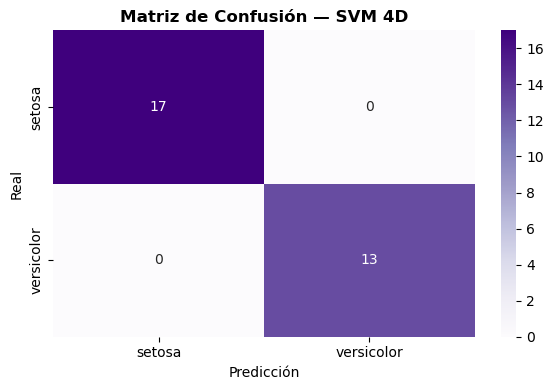

In [8]:
modelo_svm = SVC(kernel='linear', C=1.0, random_state=42)
modelo_svm.fit(X_train_scaled, y_train)

predicciones_svm = modelo_svm.predict(X_test_scaled)

print("=" * 55)
print("  REPORTE DE RENDIMIENTO — SVM 4D (kernel=linear)")
print("=" * 55)
print(classification_report(y_test, predicciones_svm, target_names=class_names))

cm = confusion_matrix(y_test, predicciones_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión — SVM 4D', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔄 8. Comparativa de Kernels

El **kernel** define cómo la SVM transforma el espacio para separar los datos.

| Kernel | Qué hace | ¿Cuándo usarlo? |
|---|---|---|
| `linear` | Hiperplano recto | Datos linealmente separables, muchas features, texto/NLP |
| `rbf` | Curvas gaussianas | Datos no lineales, caso general — es el más versátil |
| `poly` | Curvas polinomiales | Relaciones polinomiales conocidas entre features |

### ¿Cuándo usar cada uno?

**`linear`** — Usarlo cuando:
- Los datos ya se pueden separar con una línea recta (como setosa vs versicolor)
- Tienes muchas features y pocos datos (texto, NLP, clasificación de emails)
- Quieres un modelo rápido e interpretable
- Es tu punto de partida: si linear funciona bien, no compliques más

**`rbf`** (Radial Basis Function) — Úsalo cuando:
- Los datos forman grupos circulares o irregulares (no separables con línea recta)
- No sabes qué kernel usar — **rbf es el default recomendado**
- Tienes datos de imágenes, señales biológicas, sensores
- El kernel linear no da buenos resultados

**`poly`** — Úsalo cuando:
- Sabes que la relación entre features es polinomial (por ejemplo, en física o química)
- Estás haciendo visión por computadora o reconocimiento de caracteres
- Úsalo con cuidado: con grado alto puede causar overfitting fácilmente

---
## 🌸 9. Predicción con flor nueva

In [10]:
# Formato: [sepal_length, sepal_width, petal_length, petal_width]
florNueva = [[1.0, 1.0, 1.5, 1.0]]

# ⚠️ Siempre normalizar con el MISMO scaler del entrenamiento
florNueva_scaled = scaler.transform(florNueva)

prediccion = modelo_svm.predict(florNueva_scaled)
print(f"Medidas: sepal_length=1.0, sepal_width=1.0, petal_length=1.5, petal_width=1.0")
print(f"\nPredicción: [{prediccion[0]}] → '{class_names[prediccion[0]]}'")

# Otras flores de prueba
flores_prueba = [
    [5.1, 3.5, 1.4, 0.2],   # Típica setosa
    [6.0, 2.9, 4.5, 1.5],   # Típica versicolor
    [1.0, 1.0, 1.5, 1.0],   # La del profe
]
flores_scaled = scaler.transform(flores_prueba)
preds = modelo_svm.predict(flores_scaled)

print("\nPredicciones para varias flores:")
print(f"{'Medidas':<35} {'Pred':>5} {'Especie':<15}")
print("-" * 56)
for flor, pred in zip(flores_prueba, preds):
    print(f"{str(flor):<35} [{pred}]   {class_names[pred]}")

Medidas: sepal_length=1.0, sepal_width=1.0, petal_length=1.5, petal_width=1.0

Predicción: [0] → 'setosa'

Predicciones para varias flores:
Medidas                              Pred Especie        
--------------------------------------------------------
[5.1, 3.5, 1.4, 0.2]                [0]   setosa
[6.0, 2.9, 4.5, 1.5]                [1]   versicolor
[1.0, 1.0, 1.5, 1.0]                [0]   setosa


---
## 📝 10. Resumen: SVM vs Árbol de Decisión

| Característica | SVM | Árbol de Decisión |
|---|---|---|
| **¿Necesita normalizar?** | ✅ Sí (usa distancias) | ❌ No (usa reglas) |
| **¿Interpretable visualmente?** | Solo en 2D/3D | ✅ Siempre (árbol) |
| **Parámetro clave** | C (margen), kernel | max_depth |
| **Overfitting** | Menos propenso con C bajo | Propenso sin max_depth |
| **Con datos pequeños** | ✅ Funciona bien | ✅ Funciona bien |
| **Con muchas features** | ✅ Muy bueno | ⚠️ Puede sobreajustar |

### ¿Por qué también veremos K-Means?
SVM y Árboles son **aprendizaje supervisado** — necesitan etiquetas para entrenar.
**K-Means** es **aprendizaje no supervisado** — encuentra grupos sin conocer las clases.
Es útil cuando no tienes datos etiquetados o quieres descubrir patrones ocultos en los datos.